# Colab T4 GPU Destekli Basit OCR

Bu notebook Colab üzerinde **T4 GPU** kullanarak hızlı OCR (Optik Karakter Tanıma) yapmak için hazırlanmıştır.

In [ ]:
# 1. Gerekli kütüphaneyi kurun
!pip install easyocr


--- OCR SONUÇLARI ---

Güven: %97.98 | Metin: Universal segmentation model
Güven: %96.95 | Metin: valid masks
Güven: %100.00 | Metin: confidence
Güven: %99.98 | Metin: score
Güven: %100.00 | Metin: image
Güven: %95.75 | Metin: lightweight
Güven: %97.55 | Metin: confidence
Güven: %100.00 | Metin: encoder
Güven: %98.32 | Metin: mask decoder
Güven: %99.99 | Metin: score
Güven: %100.00 | Metin: image
Güven: %99.86 | Metin: confidence
Güven: %99.98 | Metin: score
Güven: %100.00 | Metin: image
Güven: %99.93 | Metin: prompt encoder
Güven: %82.88 | Metin: embeddings
Güven: %100.00 | Metin: down
Güven: %83.63 | Metin: (x,y,fglbg)
Güven: %100.00 | Metin: sample
Güven: %82.05 | Metin: (xl,yl),(x2y2)
Güven: %100.00 | Metin: mask
Güven: %100.00 | Metin: points
Güven: %99.97 | Metin: box
Güven: %100.00 | Metin: text


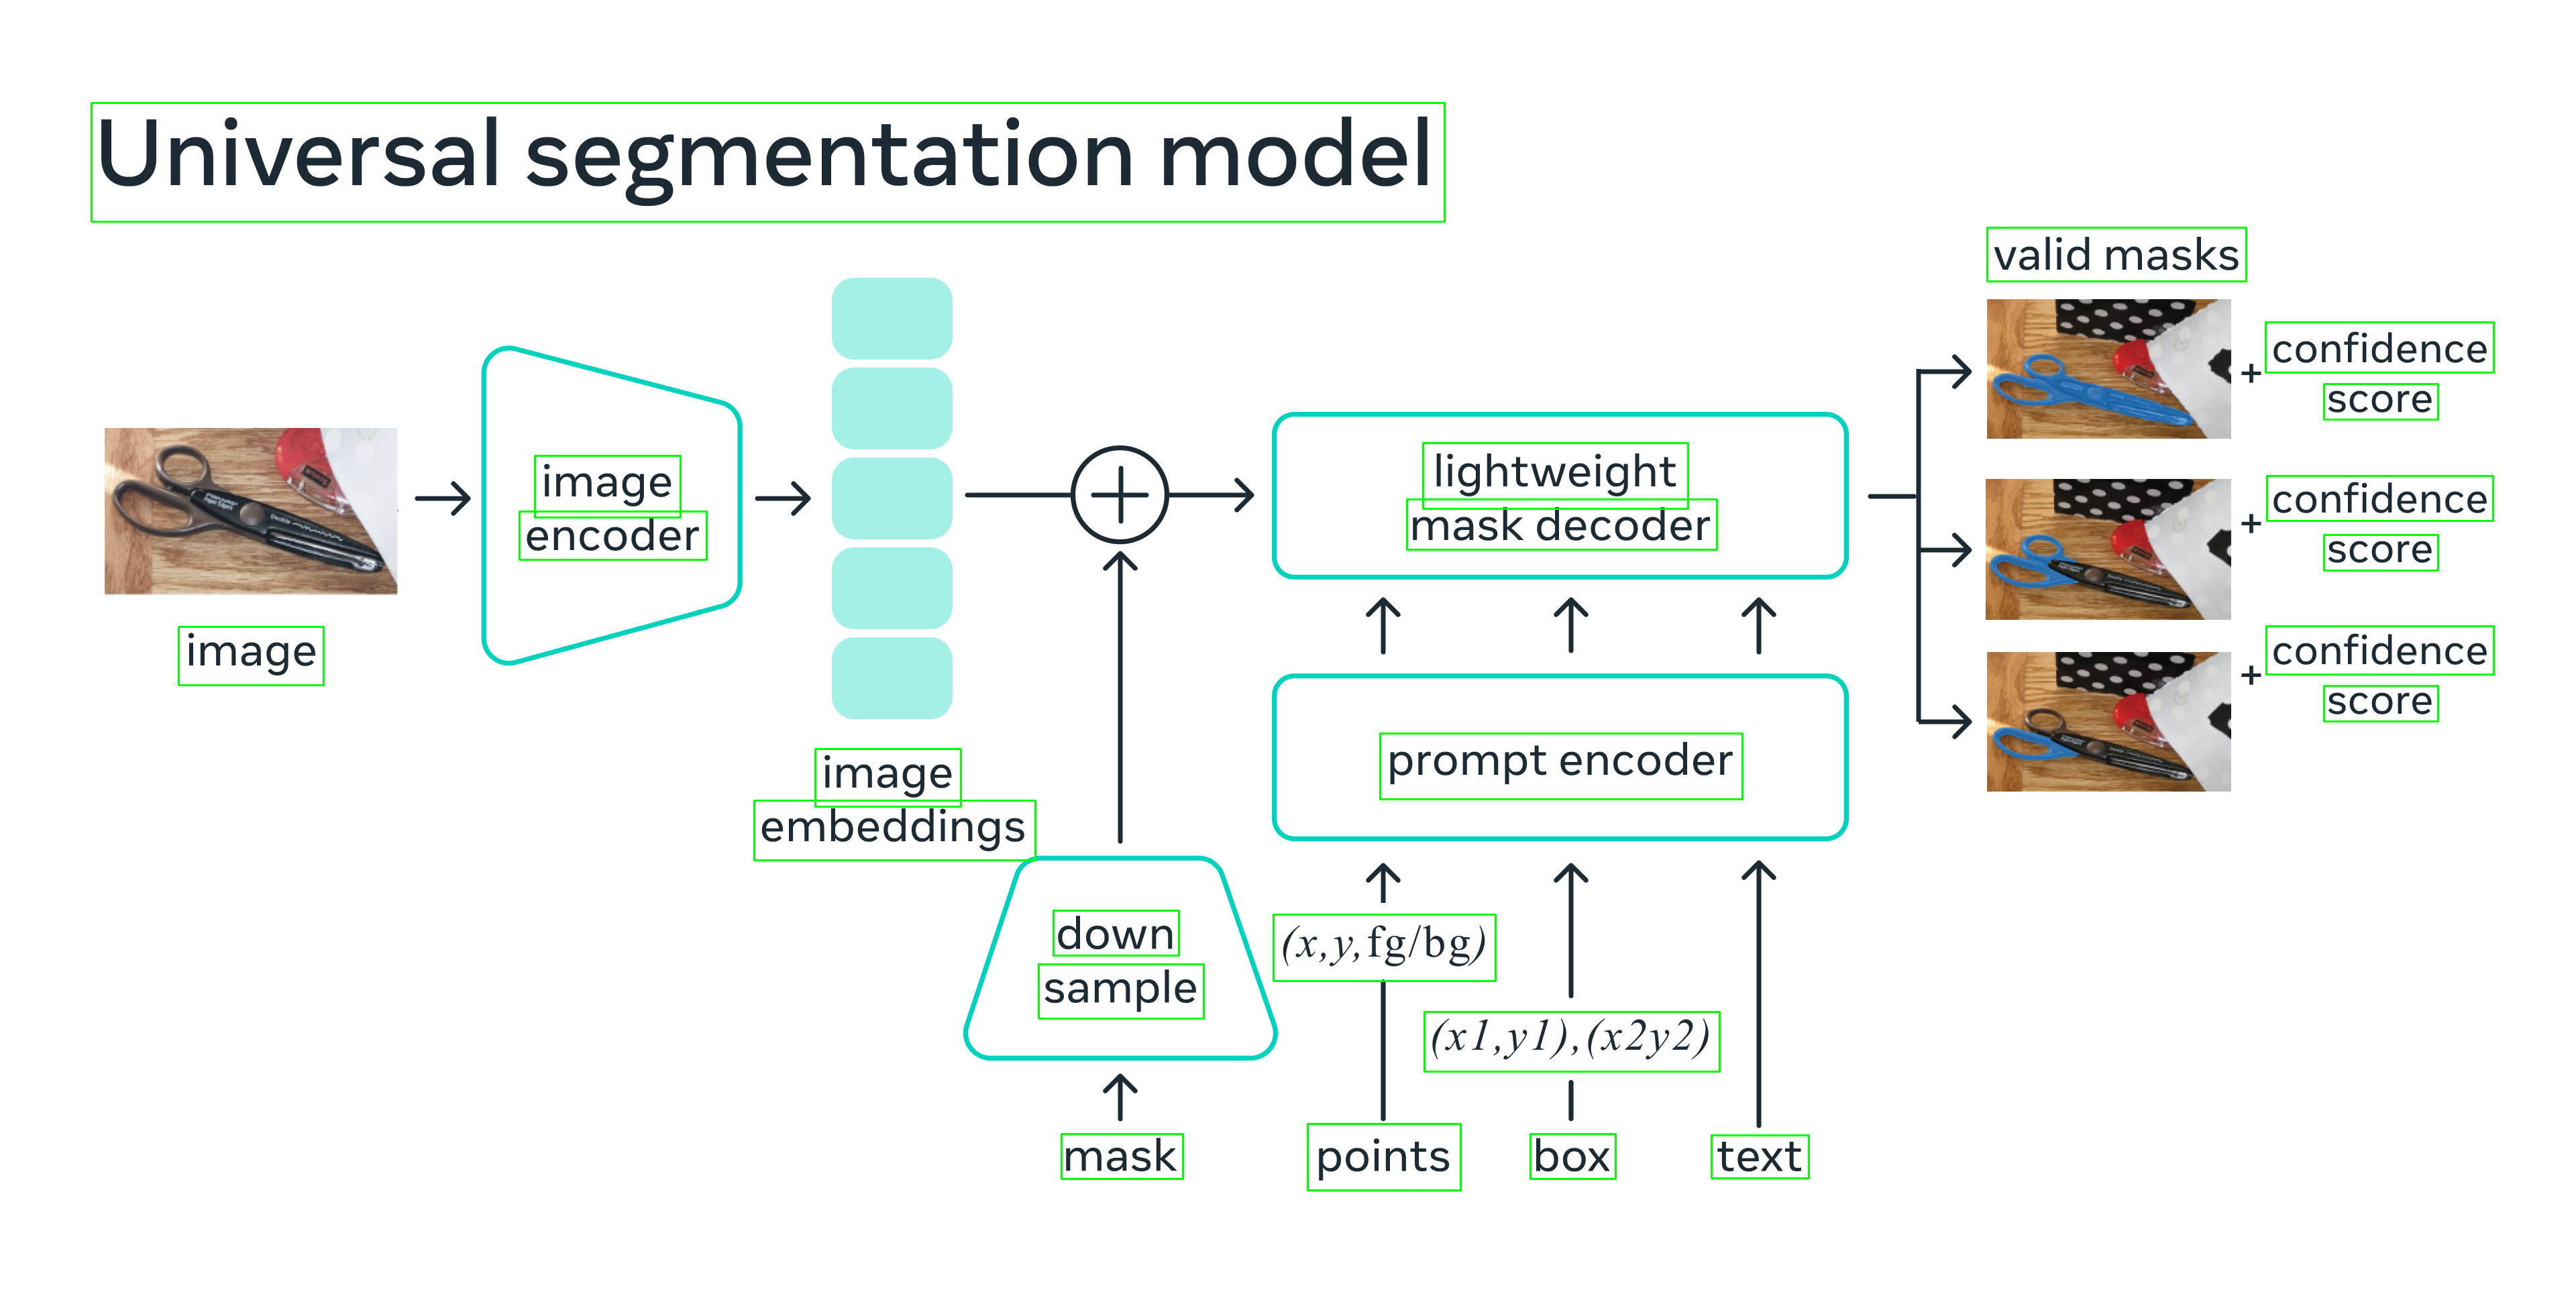

In [3]:
import easyocr
import cv2
from google.colab.patches import cv2_imshow
import os

# 2. Reader'ı başlatın (gpu=True parameteresi T4 GPU'yu kullanır)
reader = easyocr.Reader(['tr', 'en'], gpu=True)

# 3. OCR yapılacak resmin yolunu belirtin
# Not: arch.png dosyası aynı dizinde olmalıdır
image_path = 'arch.png' 

if os.path.exists(image_path):
    # 4. Metni oku
    results = reader.readtext(image_path)

    # 5. Sonuçları görselleştir
    img = cv2.imread(image_path)
    
    print("\n--- OCR SONUÇLARI ---\n")
    for (bbox, text, prob) in results:
        print(f"Güven: %{prob*100:.2f} | Metin: {text}")
        
        (tl, tr, br, bl) = bbox
        cv2.rectangle(img, (int(tl[0]), int(tl[1])), (int(br[0]), int(br[1])), (0, 255, 0), 2)

    # 6. Sonucu göster
    cv2_imshow(img)
else:
    print(f"Hata: {image_path} bulunamadı. Lütfen resmi Colab sol menüsünden yükleyin.")